# Week 2 — OpenCV Image Basics

In this assignment, I learned the fundamentals of image preprocessing using OpenCV, Matplotlib, and PIL in Python. These techniques are important in Machine Learning, Computer Vision, and Deep Learning projects.

First, I uploaded five sample images into Google Colab and imported the required libraries such as OpenCV (`cv2`), Matplotlib, OS, and PIL. Then I read an image using `cv2.imread()` and examined its properties using `img.shape` and `img.dtype`. The shape helped me understand the image dimensions as height, width, and color channels, while the datatype `uint8` showed that pixel values range from 0 to 255.

Next, I learned that OpenCV reads images in BGR format instead of RGB. To display the image correctly using Matplotlib, I converted the image from BGR to RGB using `cv2.cvtColor()`. After that, I resized the image to `224 × 224` pixels using `cv2.resize()`, which is a common image size used in many deep learning models. I then saved the resized image using `cv2.imwrite()` and verified its dimensions using `PIL.Image.open()`.

I also converted the image into grayscale using `cv2.COLOR_BGR2GRAY` to understand how images can be simplified by removing color information. I displayed both the original and grayscale images side by side using Matplotlib subplots.

Further, I converted the image into HSV color space using `cv2.COLOR_BGR2HSV`. I separated and displayed the Hue, Saturation, and Value channels individually to understand how HSV stores color information. HSV is useful for color filtering and object detection tasks.

I then applied histogram equalization using `cv2.equalizeHist()` to improve the contrast and brightness of grayscale images. This technique is especially useful when images are dark or poorly lit. I compared the image before and after equalization to observe the improvement in image quality.

Finally, I automated image preprocessing by looping through all five uploaded images. For each image, I performed resizing, RGB conversion, and saving into a new folder called `sample_images_processed`. I also printed a summary showing the filename, original shape, and resized shape.

Through this assignment, I gained practical experience in image loading, visualization, resizing, grayscale conversion, HSV conversion, histogram equalization, and batch image preprocessing using Python and OpenCV.

In [1]:
pip install opencv-python pillow matplotlib

In [23]:
from google.colab import files
uploaded = files.upload()

Saving img1.jpg to img1 (1).jpg
Saving img2.jpg to img2 (1).jpg
Saving img3.jpg to img3.jpg
Saving img4.jpg to img4.jpg
Saving img5.jpg to img5.jpg


Upload Images in Google Colab

In [24]:
import cv2
import matplotlib.pyplot as plt
import os
from PIL import Image

Import Libraries

In [25]:
img = cv2.imread("img1.jpg")

print("Shape:", img.shape)
print("Datatype:", img.dtype)

Shape: (1600, 1200, 3)
Datatype: uint8


Convert BGR to RGB and Display

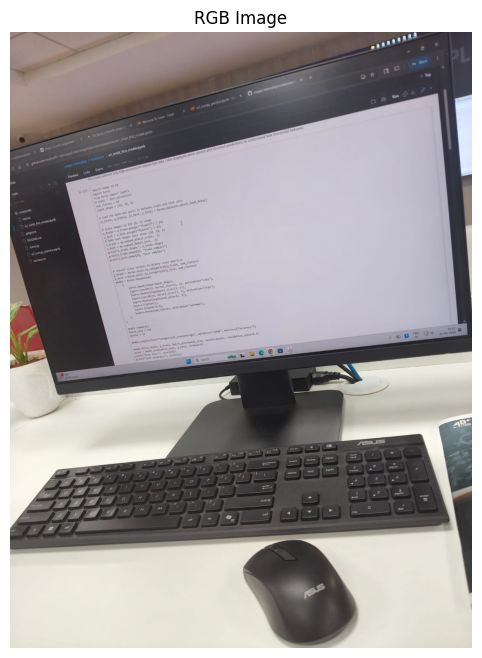

In [26]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.title("RGB Image")
plt.axis("off")
plt.show()

Resize Image to 224 × 224

In [27]:
resized = cv2.resize(img_rgb, (224, 224))

print("New Shape:", resized.shape)

New Shape: (224, 224, 3)


Save Resized Image

In [28]:
cv2.imwrite("resized_img.jpg",
            cv2.cvtColor(resized, cv2.COLOR_RGB2BGR))

True

Verify Saved Image Size Using PIL

In [29]:
saved_img = Image.open("resized_img.jpg")

print(saved_img.size)

(224, 224)


Convert Image to Grayscale

In [30]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print(gray.shape)

(1600, 1200)


Display Original and Grayscale Side by Side

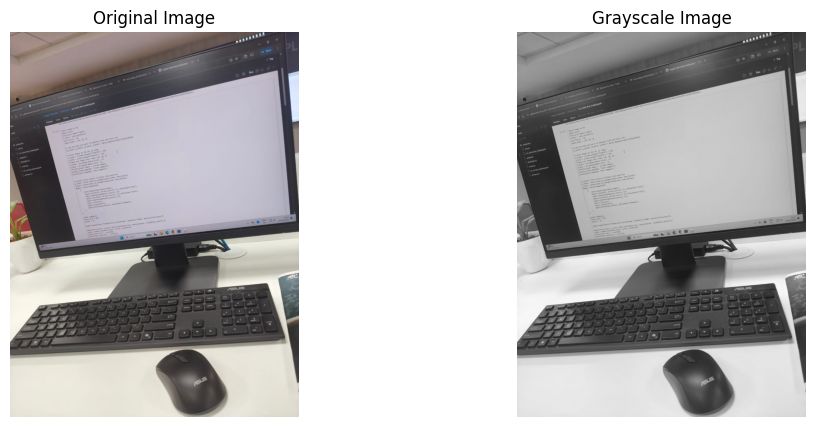

In [31]:
plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

# Grayscale
plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

Convert to HSV

In [32]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

Split HSV Channels

In [33]:
h, s, v = cv2.split(hsv)

Display HSV Channels

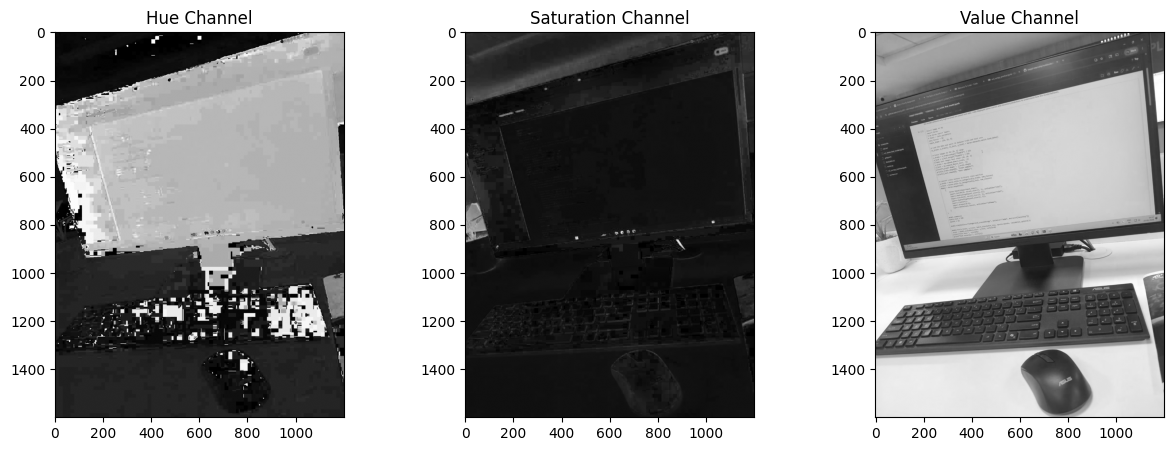

In [34]:
plt.figure(figsize=(15,5))

# Hue
plt.subplot(1,3,1)
plt.imshow(h, cmap='gray')
plt.title("Hue Channel")

# Saturation
plt.subplot(1,3,2)
plt.imshow(s, cmap='gray')
plt.title("Saturation Channel")

# Value
plt.subplot(1,3,3)
plt.imshow(v, cmap='gray')
plt.title("Value Channel")

plt.show()

Histogram Equalization

In [35]:
equalized = cv2.equalizeHist(gray)

Compare Before and After Equalization

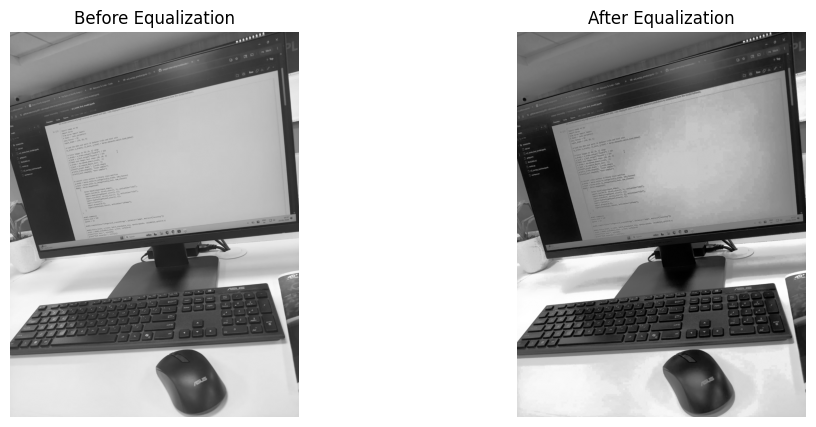

In [36]:
plt.figure(figsize=(12,5))

# Before
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Before Equalization")
plt.axis("off")

# After
plt.subplot(1,2,2)
plt.imshow(equalized, cmap='gray')
plt.title("After Equalization")
plt.axis("off")

plt.show()

Create Processed Images Folder

In [37]:
os.makedirs("sample_images_processed", exist_ok=True)

Process All 5 Images Automatically

In [38]:
image_files = [
    "img1.jpg",
    "img2.jpg",
    "img3.jpg",
    "img4.jpg",
    "img5.jpg"
]

for filename in image_files:

    # Read image
    img = cv2.imread(filename)

    if img is None:
        print(f"{filename} not found")
        continue

    # Original shape
    original_shape = img.shape

    # Convert to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    resized = cv2.resize(img_rgb, (224, 224))

    # Save image
    save_path = os.path.join("sample_images_processed", filename)

    cv2.imwrite(save_path,
                cv2.cvtColor(resized, cv2.COLOR_RGB2BGR))

    # Print summary
    print(f"{filename} | Original: {original_shape} | New: {resized.shape}")

img1.jpg | Original: (1600, 1200, 3) | New: (224, 224, 3)
img2.jpg | Original: (360, 539, 3) | New: (224, 224, 3)
img3.jpg | Original: (1500, 844, 3) | New: (224, 224, 3)
img4.jpg | Original: (1449, 766, 3) | New: (224, 224, 3)
img5.jpg | Original: (899, 1599, 3) | New: (224, 224, 3)


Plot Histogram Graph

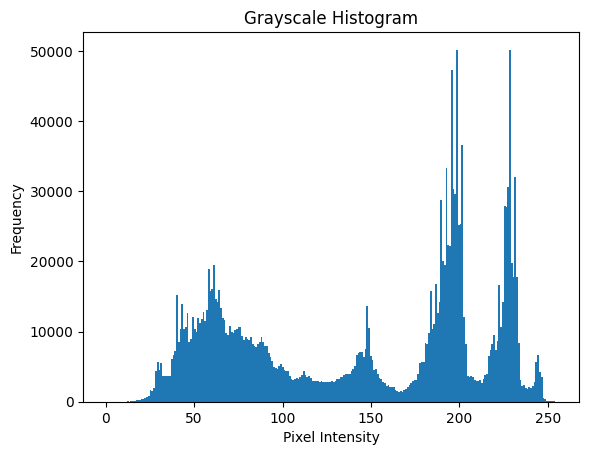

In [39]:
plt.hist(gray.ravel(), bins=256)

plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

Download Processed Folder

In [40]:
from google.colab import files
import shutil

shutil.make_archive("processed_images", 'zip', "sample_images_processed")

files.download("processed_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>